In [3]:
# DECISION TREE — Customer Churn Prediction


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import os

# Set output directory for plots (works in both .py and .ipynb)
try:
    output_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    output_dir = os.getcwd()



### STEP 1: Load & Inspect Data


In [4]:

# Path relative to script location
dataset_path = os.path.join(os.path.dirname(output_dir), 'dataset', 'telco_churn.csv')
print(f'Loading dataset from: {dataset_path}')

df = pd.read_csv(dataset_path)
print(f'Dataset shape: {df.shape}')
print(df.head())

# ── 1a. Identify Categorical Columns before dropping ────────
# The original script mentions encoding all remaining categorical columns
# To reproduce the EDA correlation map exactly with all features, we need numeric values.



Loading dataset from: c:\Users\Dasun\Desktop\ml\customer-churn-prediction-ml\dataset\telco_churn.csv
Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4           

### STEP 2: Preprocess


Nulls before drop: 11
Shape after drop: (7032, 21)
Churn distribution:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


C:\Users\Dasun\AppData\Local\Temp\ipykernel_19952\1172170515.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Saved correlation_heatmap.png


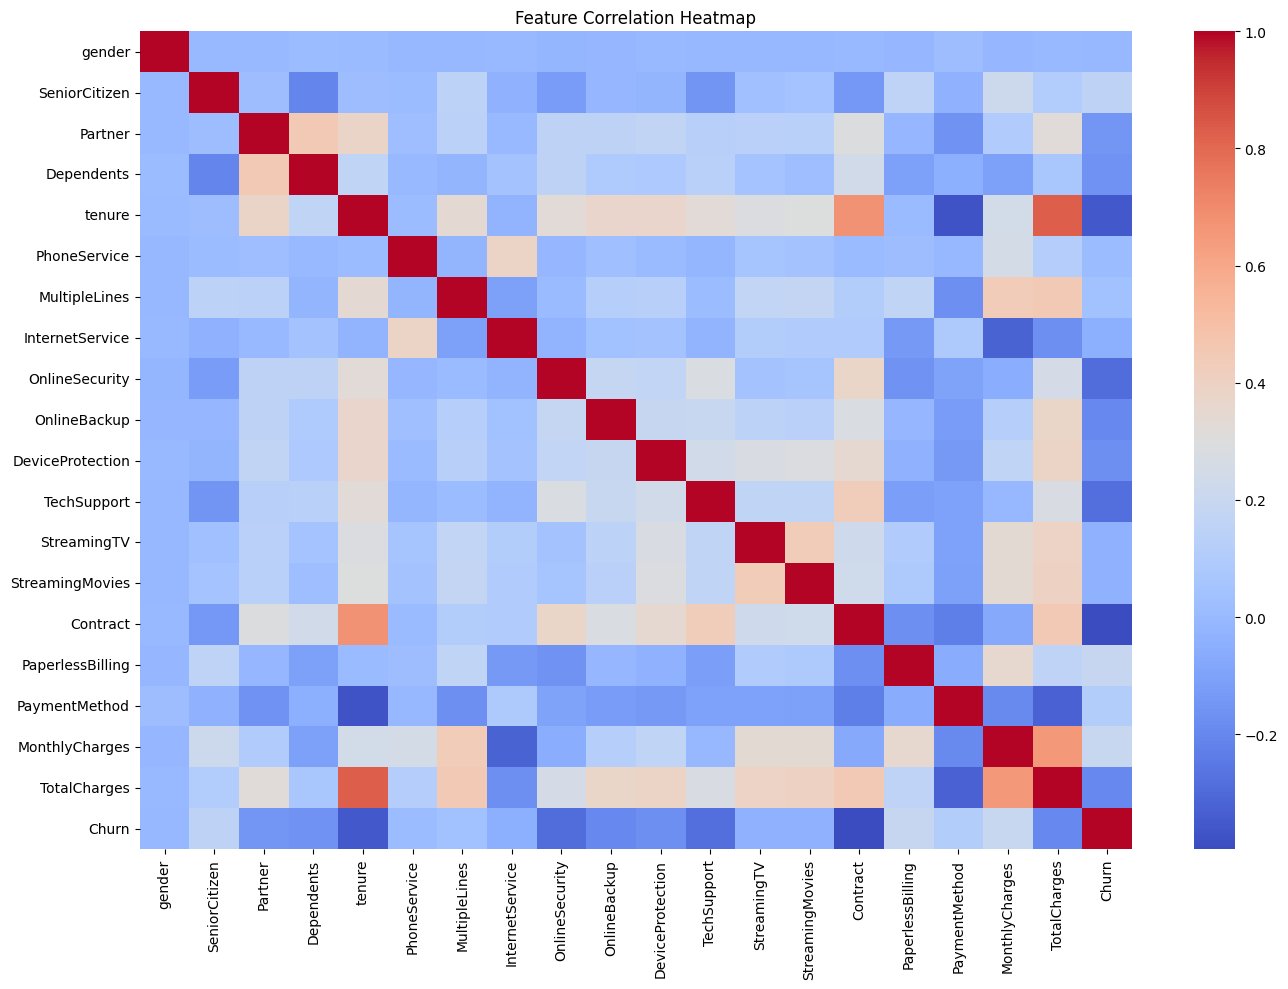

In [5]:

# Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Nulls before drop:', df.isnull().sum().sum())
df.dropna(inplace=True)
print('Shape after drop:', df.shape)

# Drop Irrelevant Column
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Encode Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all remaining categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# ── Exploratory Data Analysis (EDA) ─────────────────────────
print('Churn distribution:')
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=150)
print("Saved correlation_heatmap.png")
# plt.show() # Not showing interactively during script execution



### STEP 3: Feature / Target Split


In [6]:

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')



Train: (5625, 19), Test: (1407, 19)


### STEP 4: Train Decision Tree (Initial)


In [7]:

dt_model = DecisionTreeClassifier(
    criterion='gini',          # Split quality measure
    max_depth=5,               # Limit depth to prevent overfitting
    min_samples_split=10,      # Min samples to split a node
    min_samples_leaf=5,        # Min samples in leaf
    class_weight='balanced',   # Handle class imbalance
    random_state=42            # Reproducibility
)
dt_model.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

### STEP 5: Evaluate


In [8]:

y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f'Accuracy:  {acc:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))



Accuracy:  0.7299
ROC-AUC:   0.8152

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.72      0.80      1033
       Churn       0.49      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### STEP 6: Confusion Matrix Plot


Saved dt_confusion_matrix.png


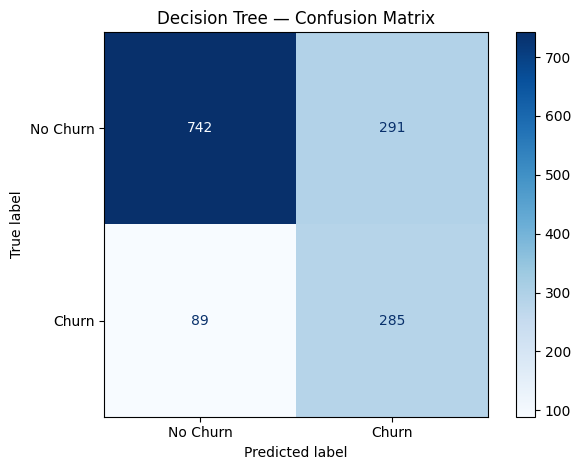

In [9]:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dt_confusion_matrix.png'), dpi=150)
print("Saved dt_confusion_matrix.png")



### STEP 7: Visualise Decision Tree


Saved decision_tree_visual.png


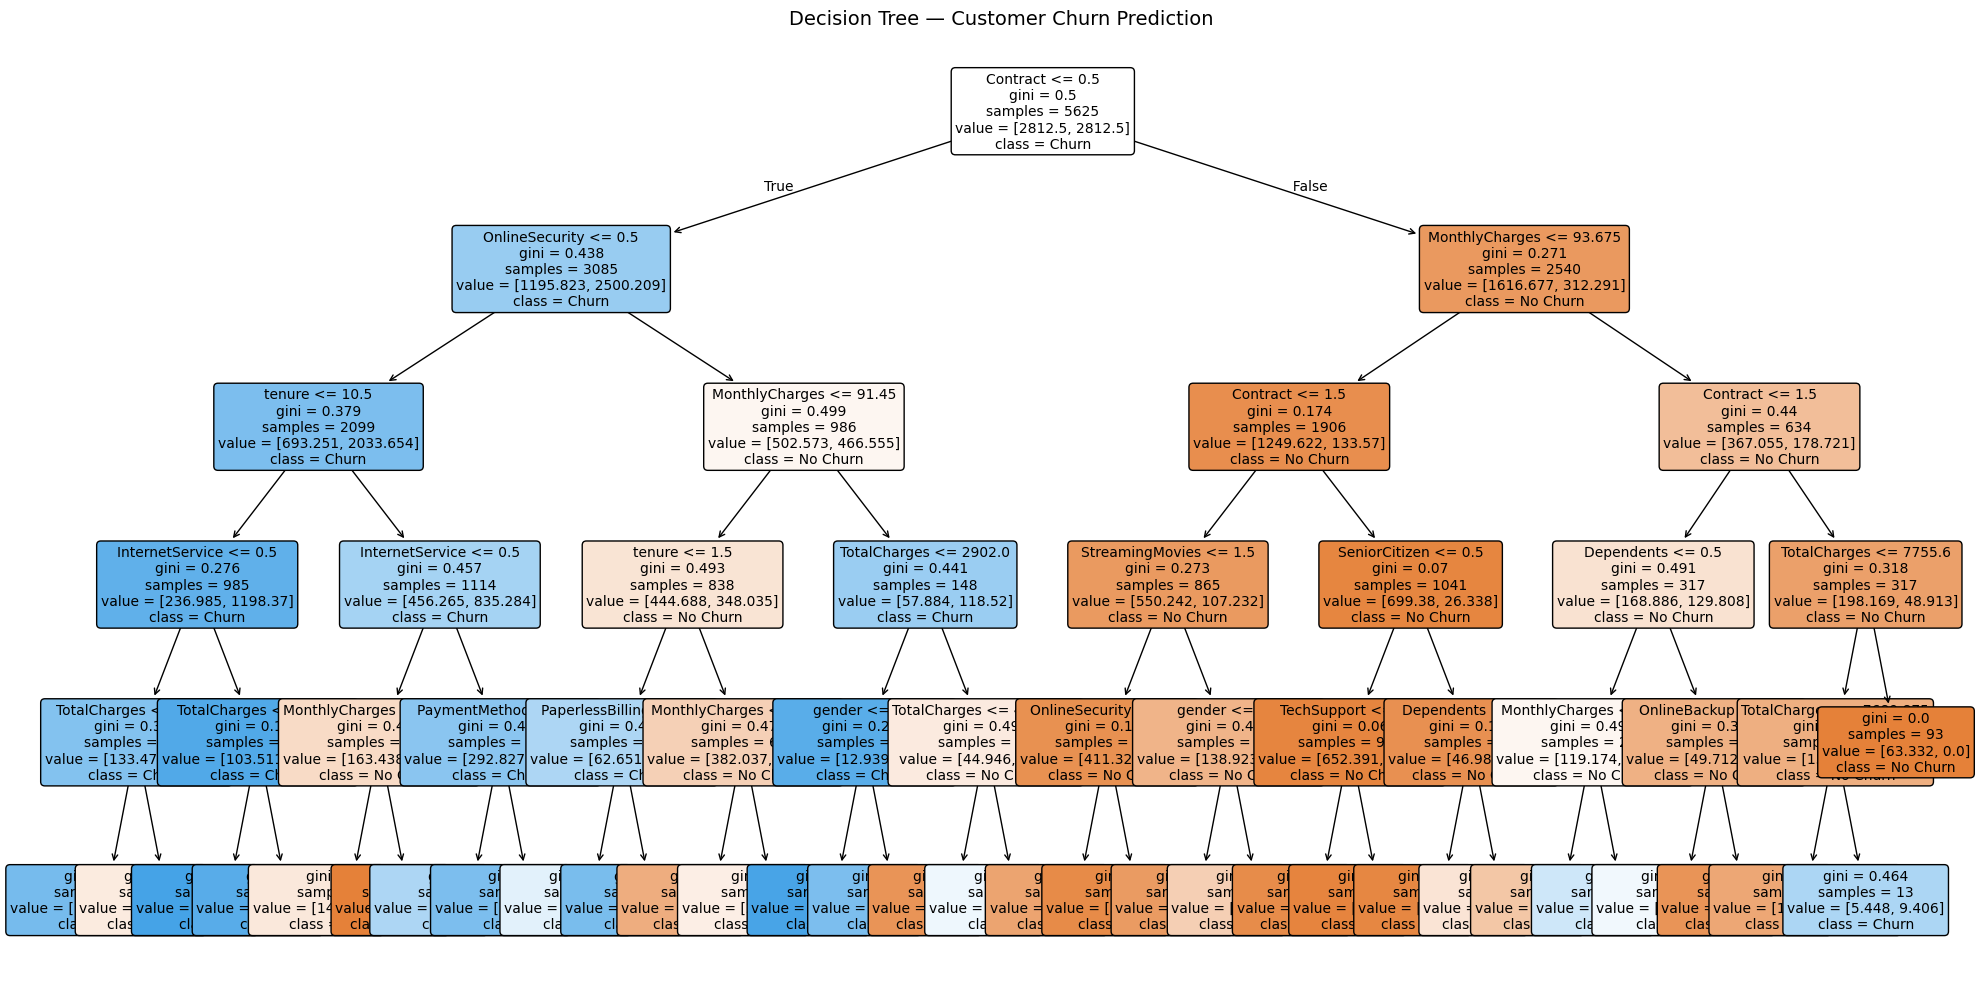

In [10]:

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree — Customer Churn Prediction', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'decision_tree_visual.png'), dpi=150, bbox_inches='tight')
print("Saved decision_tree_visual.png")



### STEP 8: Feature Importance


Saved dt_feature_importance.png


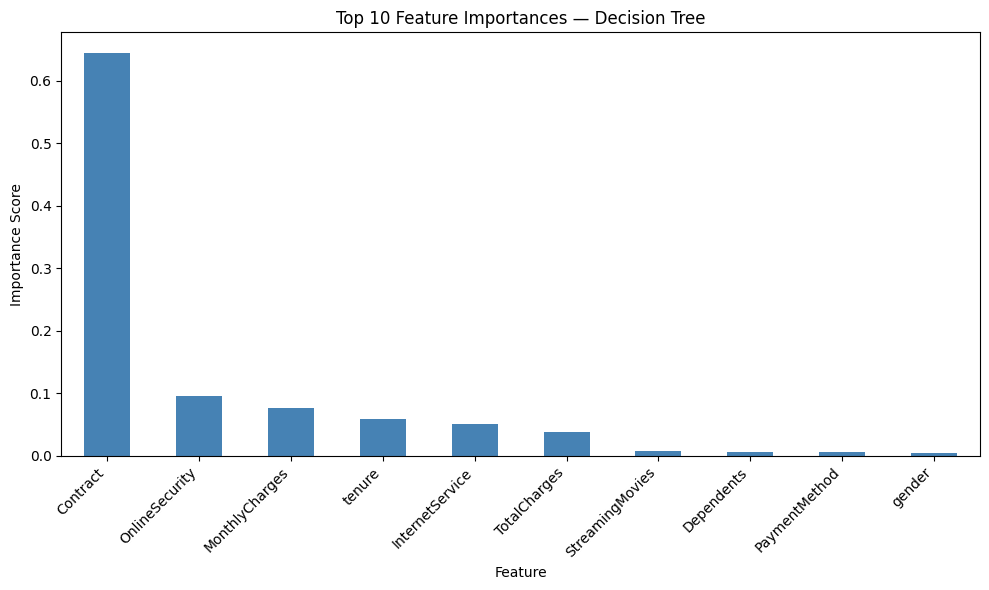

In [11]:

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sorted.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances — Decision Tree')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dt_feature_importance.png'), dpi=150)
print("Saved dt_feature_importance.png")



### STEP 9: ROC Curve


Saved dt_roc_curve.png

Performing Overfitting Analysis (Depth vs Accuracy)...
Saved dt_depth_analysis.png

At max_depth=5:
Training Accuracy: 0.7653
Test Accuracy:     0.7299
Overfitting Gap:   0.0354


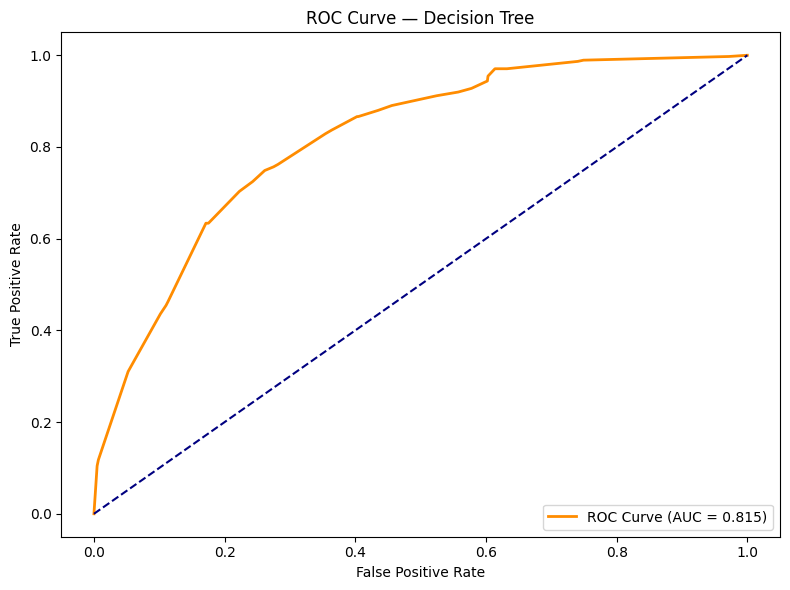

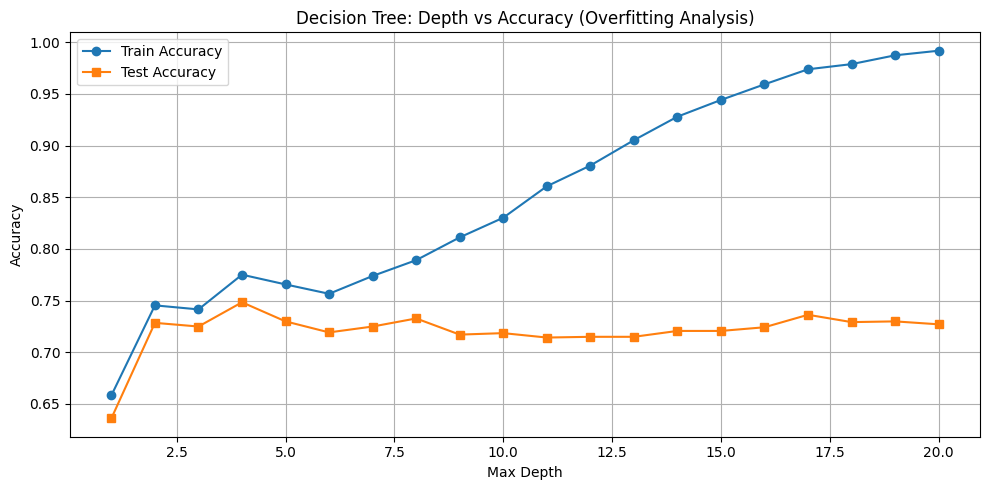

In [12]:

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dt_roc_curve.png'), dpi=150)
print("Saved dt_roc_curve.png")

# ── OVERFITTING ANALYSIS (DEPTH VS ACCURACY) ────────────────
print("\nPerforming Overfitting Analysis (Depth vs Accuracy)...")
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores,  label='Test Accuracy',  marker='s')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Depth vs Accuracy (Overfitting Analysis)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dt_depth_analysis.png'), dpi=150)
print("Saved dt_depth_analysis.png")

train_acc = accuracy_score(y_train, dt_model.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_model.predict(X_test))
print(f'\nAt max_depth=5:')
print(f'Training Accuracy: {train_acc:.4f}')
print(f'Test Accuracy:     {test_acc:.4f}')
print(f'Overfitting Gap:   {train_acc - test_acc:.4f}')



### STEP 10: Hyperparameter Tuning with GridSearchCV


In [13]:

print("\nRunning GridSearchCV for Hyperparameter Tuning...")
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,      # Use all CPU cores
    verbose=1
)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV AUC:    ', round(grid_search.best_score_, 4))




Running GridSearchCV for Hyperparameter Tuning...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV AUC:     0.8257


### STEP 11: Evaluate Tuned Model


In [14]:

best_dt = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test)
y_prob_tuned = best_dt.predict_proba(X_test)[:, 1]

print('\nTuned Model Accuracy:', round(accuracy_score(y_test, y_pred_tuned), 4))
print('Tuned Model AUC:     ', round(roc_auc_score(y_test, y_prob_tuned), 4))
print('\nTuned Model Classification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn','Churn']))




Tuned Model Accuracy: 0.7434
Tuned Model AUC:      0.8166

Tuned Model Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1033
       Churn       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.76      1407



### STEP 12: Cross-Validation Score


In [15]:

cv_scores = cross_val_score(best_dt, X, y, cv=10, scoring='accuracy')
print(f'\n10-fold CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print("\nScript completed successfully.")



10-fold CV Accuracy: 0.7423 +/- 0.0186

Script completed successfully.
